**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

OUTPUT_DIR = os.getcwd()

ALPHA_RANGE = np.arange(0.1, 10.1, 0.1)
RHO_VALUES = [0.1, 0.3, 0.5]

**Cell 2 — Helper functions**

In [2]:
def integrand(x, a):
    return x**a / np.sqrt(1 - x**2)

def upper_bound(rho):
    return (1 + ((1 - rho)**2 / (1 - rho**2)))**(-0.5)

**Cell 3 — Compute tail dependence lambda for each rho and alpha**

In [3]:
def tail_dependence_curve(rho, alpha_range):
    upbond = upper_bound(rho)
    lam = np.zeros(len(alpha_range))
    for i, a in enumerate(alpha_range):
        p, _ = quad(integrand, 0, upbond, args=(a,), limit=200)
        q, _ = quad(integrand, 0, 1, args=(a,), limit=200)
        lam[i] = p / q
    return lam

curves = {rho: tail_dependence_curve(rho, ALPHA_RANGE) for rho in RHO_VALUES}

**Cell 4 — Plot**

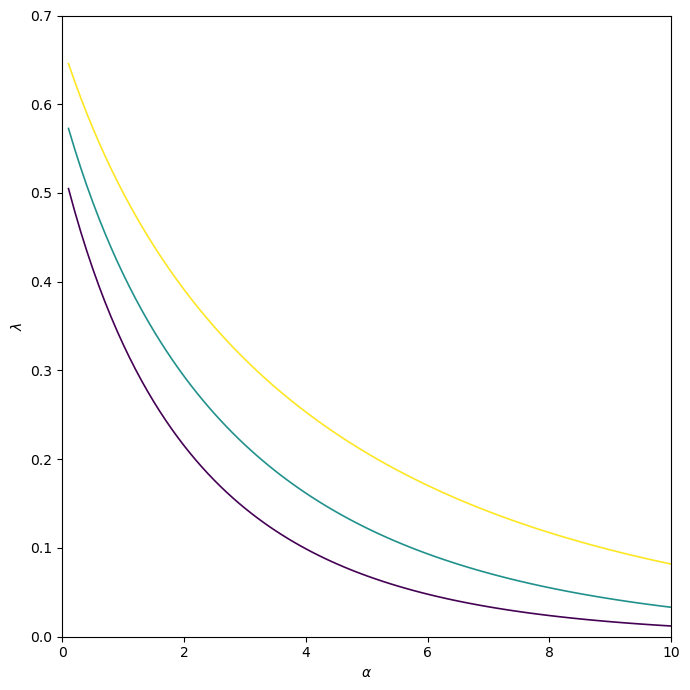

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

colors = plt.cm.viridis(np.linspace(0, 1, len(RHO_VALUES)))

for color, (rho, lam) in zip(colors, curves.items()):
    ax.plot(ALPHA_RANGE, lam, color=color, linewidth=1.2, label=rf"$\rho = {rho}$")

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\lambda$")
ax.set_xlim(0, 10)
ax.set_ylim(0, 0.7)
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tail_dep_vs_var_index.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()